### 1.Problem Statement

#####                      The goal of this project is to predict whether a bank customer will subscribe to a term deposit as a result of a marketing campaign.

##### This is a binary classification problem where the target variable indicates whether the client subscribed to a term deposit (yes or no).

#####  Machine learning models such as Logistic Regression and Random Forest will be used to predict customer behavior. Model performance will be evaluated using Confusion Matrix, F1 Score, and ROC Curve, and predictions will be interpreted using SHAP explainability techniques.

### 2.Importing Libraries

In [26]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve, roc_auc_score

### 3.Loading Dataset

In [27]:
data = pd.read_csv("bank-additional-full.csv", sep=';')

data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### 4.Dataset Overview

In [28]:
data.shape

(41188, 21)

In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [30]:
data.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [31]:
data['y'].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

### 5.Data Visualization (EDA)
#### Target Distribution

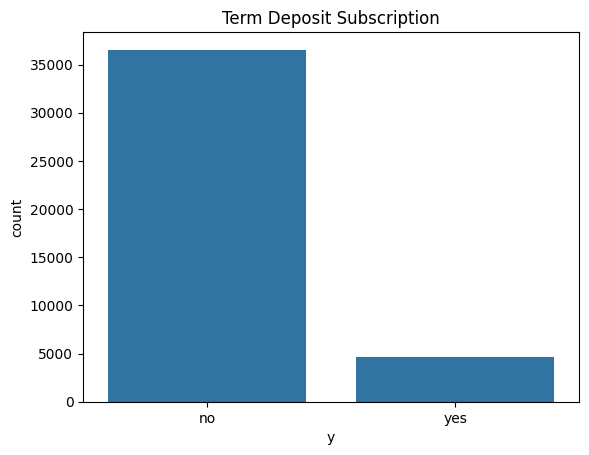

In [32]:
sns.countplot(x='y', data=data)
plt.title("Term Deposit Subscription")
plt.show()

##### So the data is imbalanced

#### Age Distribution

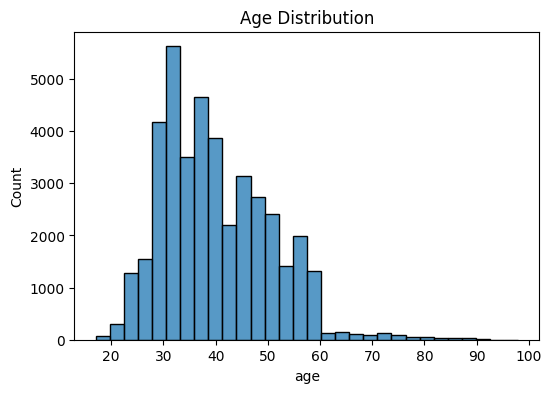

In [33]:
plt.figure(figsize=(6,4))
sns.histplot(data['age'], bins=30)
plt.title("Age Distribution")
plt.show()

#### Job Distribution

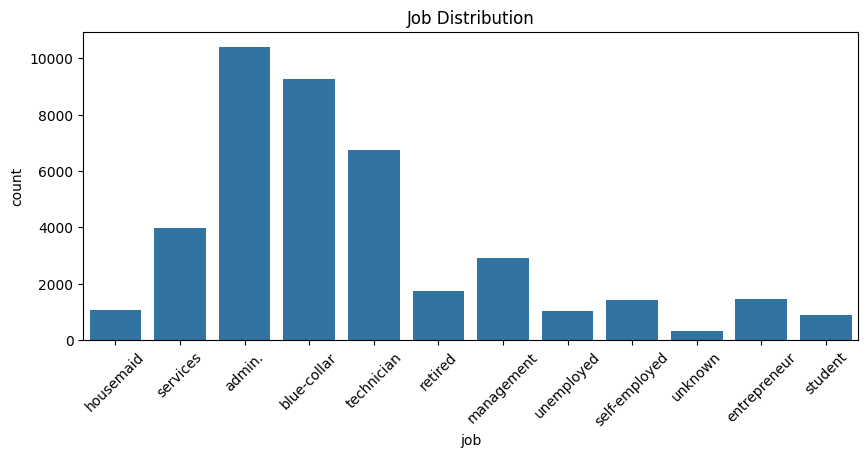

In [34]:
plt.figure(figsize=(10,4))
sns.countplot(x='job', data=data)
plt.xticks(rotation=45)
plt.title("Job Distribution")
plt.show()

#### Marital Status vs Subscription

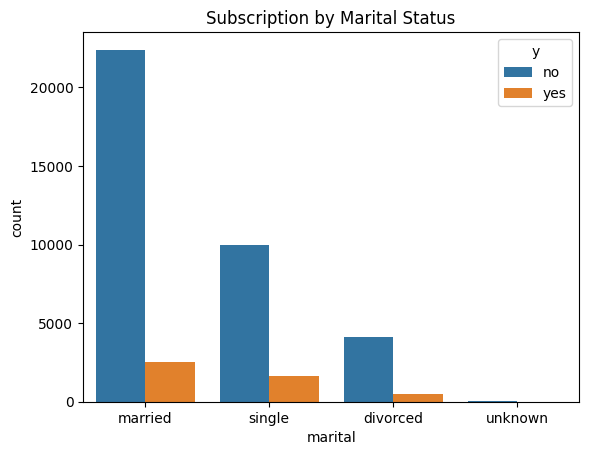

In [35]:
sns.countplot(x='marital', hue='y', data=data)
plt.title("Subscription by Marital Status")
plt.show()

### 6.Check Missing Values

In [36]:
data.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

##### This shows that pour dataset has no missing values!

### 7.Encode Categorical Variables

In [37]:
data = pd.get_dummies(data, drop_first=True)

In [38]:
data.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success,y_yes
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,True,False,False
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,True,False,False
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,True,False,False
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,True,False,False
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,False,False,True,False,False


### 8.Define Features and Target

In [39]:
y = data['y_yes']

x = data.drop('y_yes', axis=1)

### 9.Training Test Split

In [40]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)


print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

x_train shape: (32950, 53)
x_test shape: (8238, 53)
y_train shape: (32950,)
y_test shape: (8238,)


### 10.Logistic Regression & Random Forest Training and Evaluation

x_train shape: (32950, 53)
x_test shape: (8238, 53)


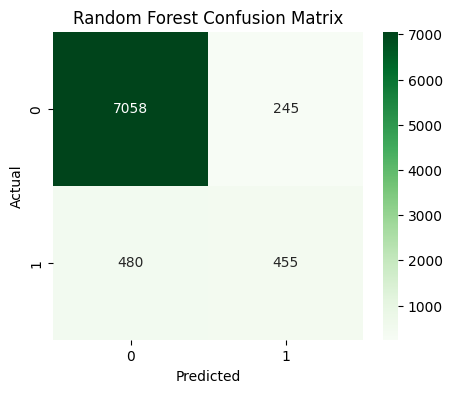

Logistic Regression
              precision    recall  f1-score   support

       False       0.93      0.97      0.95      7303
        True       0.67      0.43      0.52       935

    accuracy                           0.91      8238
   macro avg       0.80      0.70      0.74      8238
weighted avg       0.90      0.91      0.90      8238

Random Forest
              precision    recall  f1-score   support

       False       0.94      0.97      0.95      7303
        True       0.65      0.49      0.56       935

    accuracy                           0.91      8238
   macro avg       0.79      0.73      0.75      8238
weighted avg       0.90      0.91      0.91      8238

Logistic F1 Score: 0.52
Random Forest F1 Score: 0.557


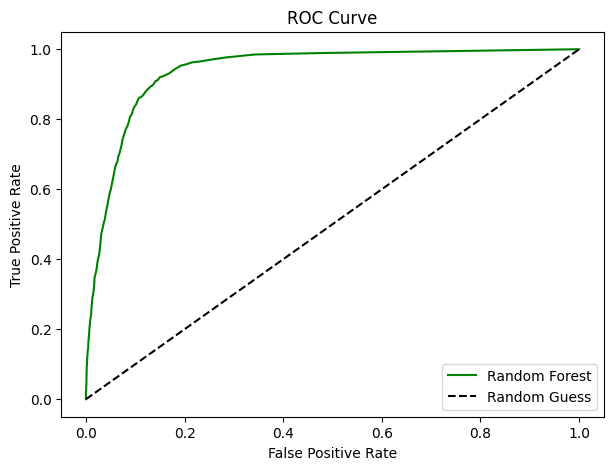

AUC Score: 0.939


In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_curve, roc_auc_score

# --- Load Dataset ---
data = pd.read_csv("bank-additional-full.csv", sep=';')

# --- Encode Categorical Variables ---
data = pd.get_dummies(data, drop_first=True)

# --- Define Features and Target ---
y = data['y_yes']
x = data.drop('y_yes', axis=1)

# --- Train Test Split ---
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

# --- Logistic Regression ---
log_model = LogisticRegression(max_iter=1000)
log_model.fit(x_train, y_train)
y_pred_log = log_model.predict(x_test)

# --- Random Forest ---
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)

# --- Confusion Matrix for Random Forest ---
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# --- Classification Reports ---
print("Logistic Regression")
print(classification_report(y_test, y_pred_log))

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

# --- F1 Scores ---
print("Logistic F1 Score:", round(f1_score(y_test, y_pred_log), 3))
print("Random Forest F1 Score:", round(f1_score(y_test, y_pred_rf), 3))

# --- ROC Curve ---
plt.figure(figsize=(7,5))
y_prob = rf_model.predict_proba(x_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, color='green', label="Random Forest")
plt.plot([0,1], [0,1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", round(roc_auc_score(y_test, y_prob), 3))

### 11.Feature Importance

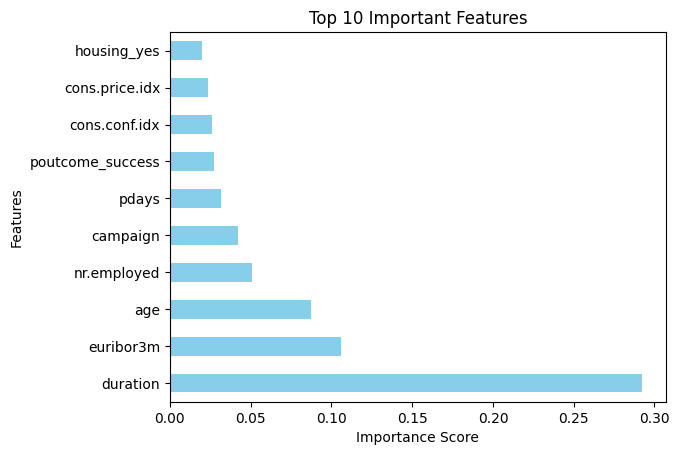

In [42]:

importances = rf_model.feature_importances_
features = x.columns

imp = pd.Series(importances, index=features)
imp.nlargest(10).plot(kind='barh', color='skyblue')
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

### Saving Trained Models

In [46]:

import joblib

joblib.dump(log_model, "logistic_model.pkl")
joblib.dump(rf_model, "random_forest_model.pkl")

print("Models saved successfully!")

Models saved successfully!


### 12.Explain 5 Model Predictions Using SHAP

shap_values type: <class 'numpy.ndarray'>
shap_values shape: (5, 53, 2)
expected_value: [0.88744006 0.11255994]

--- SHAP Explanation for Prediction 1 ---


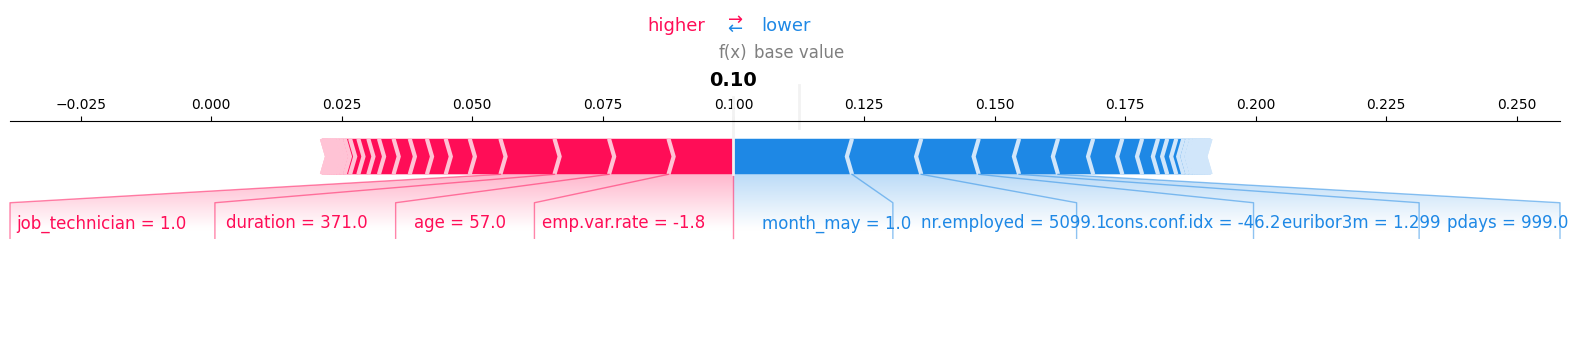


--- SHAP Explanation for Prediction 2 ---


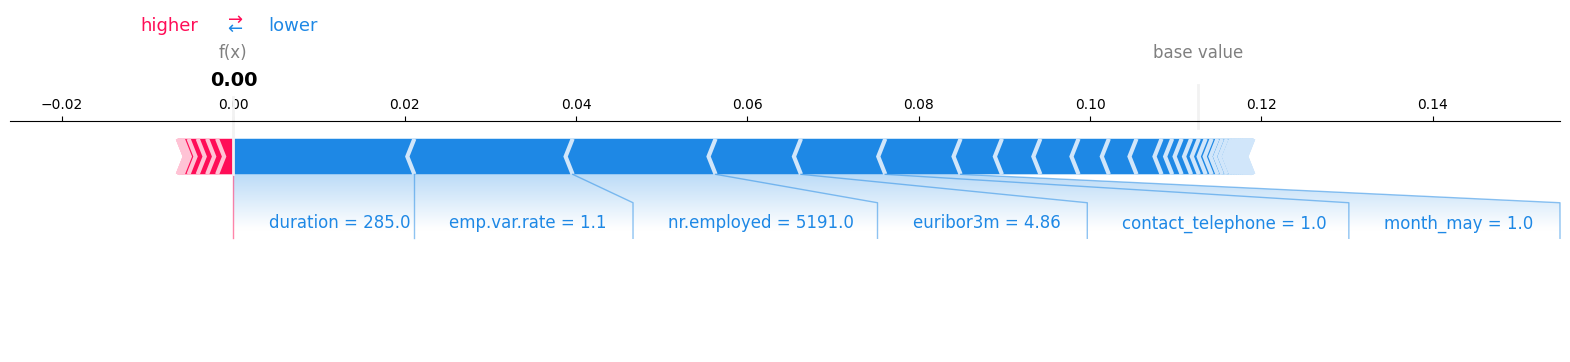


--- SHAP Explanation for Prediction 3 ---


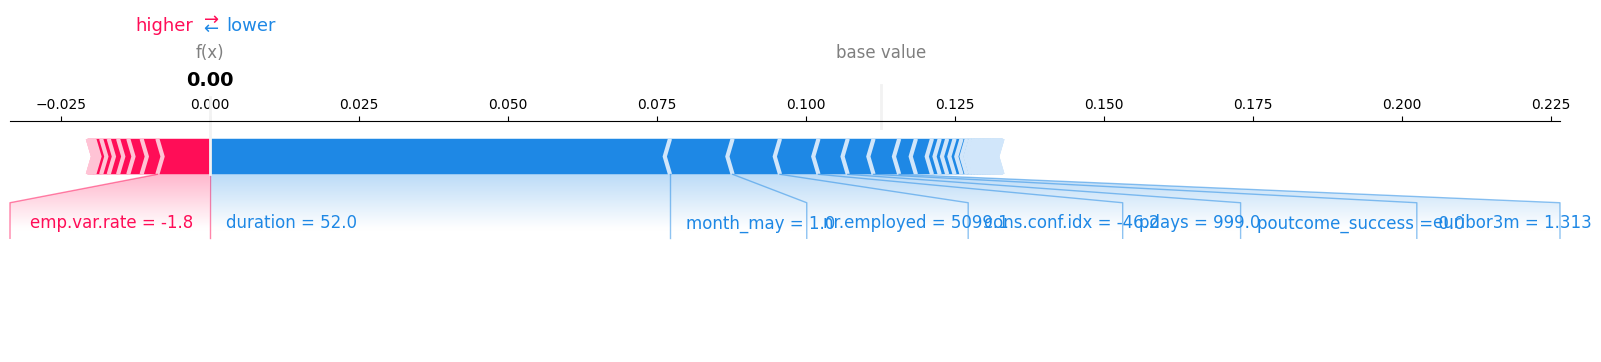


--- SHAP Explanation for Prediction 4 ---


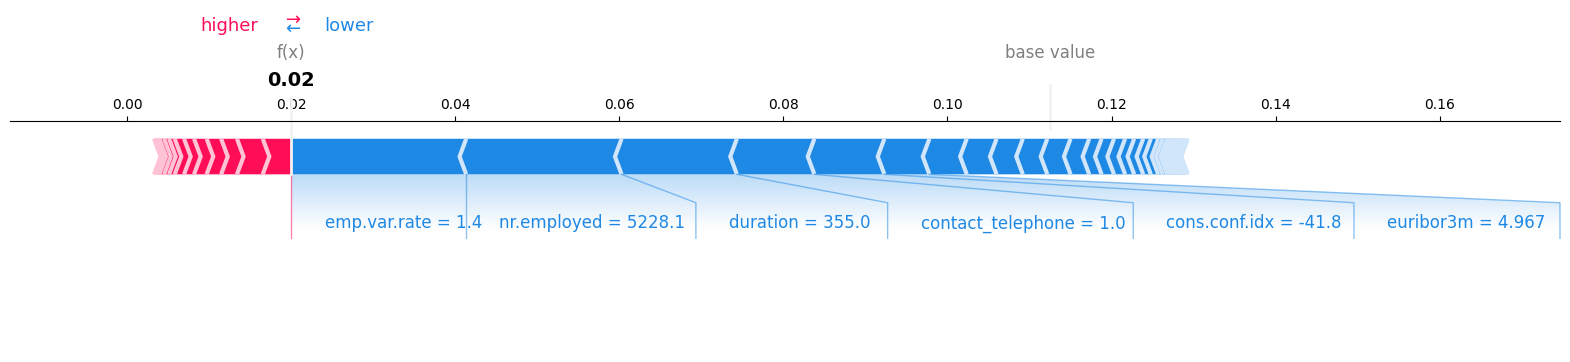


--- SHAP Explanation for Prediction 5 ---


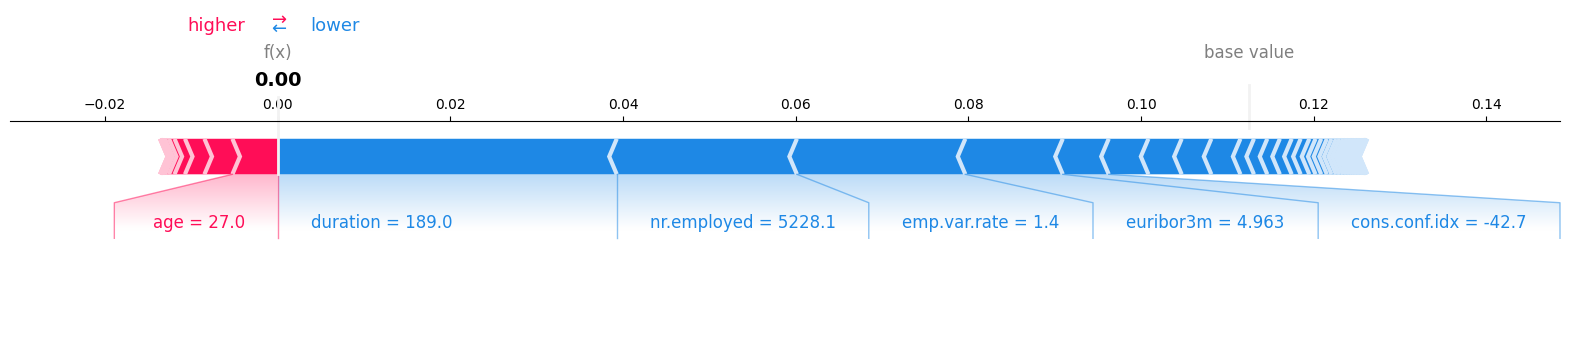

In [47]:

import shap
import numpy as np
import matplotlib.pyplot as plt

x_sample = x_test.iloc[:5]

explainer = shap.TreeExplainer(rf_model)


shap_values = explainer.shap_values(x_sample)


print("shap_values type:", type(shap_values))
print("shap_values shape:", np.array(shap_values).shape)
print("expected_value:", explainer.expected_value)


if isinstance(shap_values, list):
    
    shap_values_class1 = shap_values[1]        
    base_value = explainer.expected_value[1]
else:
    
    shap_values_class1 = shap_values[:, :, 1] 
    base_value = explainer.expected_value[1] if hasattr(explainer.expected_value, '__len__') else explainer.expected_value


for i in range(5):
    print(f"\n--- SHAP Explanation for Prediction {i+1} ---")
    shap.force_plot(
        base_value=base_value,
        shap_values=shap_values_class1[i],  
        features=x_sample.iloc[i],          
        matplotlib=True
    )
    plt.show()